In [1]:
import os,sys,copy
import torchvision
import argparse
import torch
import tqdm


# conda install -n ocr   conda-forge::libgl   for import cv2 succus

In [2]:
sys.path.append("/home/jovyan/rt-detr/rt-detr")
from src.solver.utils import output_to_smiles

os.chdir('/home/jovyan/rt-detr/rt-detr')
os.getcwd()

'/home/jovyan/rt-detr/rt-detr'

In [3]:

import src.misc.dist as dist 
from src.core import YAMLConfig 
from src.solver import TASKS
from src.data import get_coco_api_from_dataset



In [4]:
from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral
from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text
import draw_box_utils
from PIL import ImageColor
import PIL.ImageDraw as ImageDraw
import numpy as np
import src
from rdkit.Chem import Draw, AllChem

import rdkit
from rdkit import Chem


In [5]:
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F

def image_to_tensor(image_path):
    # Open the image using PIL
    image = Image.open(image_path)
    w, h = image.size
    # print("width: {}, height: {}".format(w, h))
    # Define a transform to convert the image to a tensor and normalize it
    transform = transforms.Compose([
        # transforms.Grayscale(num_output_channels=1),  # Convert to grayscale (1 channel)
        T.Resize((640, 640)),  # Resize the image to 224x224
        T.ToImageTensor(),  # Convert to Tensor (C x H x W)
        T.ConvertDtype(dtype=torch.float32)
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Optional normalization for pretrained models
    ])
    
    # Apply the transform to the image
    tensor = transform(image)
    
    return tensor,w,h

def show_atom_number(mol, label='molAtomMapNumber'):
    for atom in mol.GetAtoms():
        atom.SetProp(label, str(atom.GetIdx()))
    return mol
    
def remove_atom_number(mol, label='molAtomMapNumber'):
    # After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property
    return mol

# After performing the desired operation (e.g., showing), you can remove the property
    for atom in mol.GetAtoms():
        atom.ClearProp(label)  # Removes the atom index property

def remove_SP(input_string):
    # if "S@SP1" in input_string:
    #     input_string = input_string.replace("S@SP1", "S")
    # elif "S@SP2" in input_string:
    #     input_string = input_string.replace("S@SP2", "S")
    # elif "S@SP3" in input_string:
    #     input_string = input_string.replace("S@SP3", "S")
    input_string = re.sub(r'@SP[1-3]', '', input_string)
    return input_string

import pandas as pd
import math
from scipy.spatial import cKDTree


def assemble_atoms_with_charges(atom_list, charge_list):
    used_charge_indices=set()
    kdt = cKDTree(atom_list[['x','y']])
    for i, charge in charge_list.iterrows():
        if i in used_charge_indices:
            continue
        charge_=charge['charge']
        if charge_=='1':charge_='+'
        dist, idx_atom=kdt.query([charge_list.x[i],charge_list.y[i]], k=1)
        atom_str=atom_list.loc[idx_atom,'atom'] 
        atom_ = re.findall(r'[A-Za-z]+', atom_str)[0] + charge_
        atom_list.loc[idx_atom,'atom']=atom_

    return atom_list
    


import re
pattern =  "(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
regex = re.compile(pattern)

def atomwise_tokenizer(smi, regex=regex,exclusive_tokens = None):
    """
    Tokenize a SMILES molecule at atom-level:
        (1) 'Br' and 'Cl' are two-character tokens
        (2) Symbols with bracket are considered as tokens

    exclusive_tokens: A list of specifical symbols with bracket you want to keep. e.g., ['[C@@H]', '[nH]'].
    Other symbols with bracket will be replaced by '[UNK]'. default is `None`.
    """
    tokens = [token for token in regex.findall(smi)]
    if exclusive_tokens:
        for i, tok in enumerate(tokens):
            if tok.startswith('['):
                if tok not in exclusive_tokens:
                    tokens[i] = '[UNK]'
    return tokens



bond_labels = [13,14,15,16,17]
idx_to_labels = {0:'other',1:'C',2:'O',3:'N',4:'Cl',5:'Br',6:'S',7:'F',8:'B',
            9:'I',10:'P',11:'*',12:'Si',13:'NONE',14:'BEGINWEDGE',15:'BEGINDASH',
            16:'=',17:'#',18:'-4',19:'-2',20:'-1',21:'1',22:'+2',} #NONE is single ?


In [6]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True,use_gpu =False,
    rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer',
    lang="en")  # need to run only once to download and load model into memory

#* recong used

/home/jovyan/bo2/miniconda/envs/ocr/lib/python3.9/site-packages/paddle/utils/cpp_extension/extension_utils.py:686: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


[2024/12/16 04:38:01] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/jovyan/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/jovyan/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_le

In [7]:
home="/home/jovyan/rt-detr"
pp="tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/best_checkpoint.pth"
cc="tools/output/rtdetr_r50vd_6x_coco_real_resample_adapter_both/checkpoint0068.pth"
tt="./output/rtdetr_r50vd_6x_coco_real_resample_charge_large_adpter2/best_checkpoint.pth"
parser = argparse.ArgumentParser()
parser.add_argument('--config', '-c', type=str, default=f'{home}/rt-detr/configs/rtdetr/rtdetr_r50vd_6x_coco.yml')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample_charge_large/checkpoint0032.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/tools/output/rtdetr_r50vd_6x_coco_real_resample/checkpoint0052.pth')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{pp}')
# parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{cc}')
parser.add_argument('--resume', '-r', type=str, default=f'{home}/rt-detr/{tt}')

parser.add_argument('--tuning', '-t', type=str,)# default='/home/jovyan/model_checkpoint/rtdetr_r50vd_2x_coco_objects365_from_paddle.pth')
parser.add_argument('--test-only',default=True,)
parser.add_argument('--amp', default=False,)

args, unknown = parser.parse_known_args()#in jupyter

In [8]:
cfg = YAMLConfig(
        args.config,
        resume=args.resume, 
        use_amp=args.amp,
        tuning=args.tuning
    )
args.gpu_device=0
cfg.device=torch.device('cuda', args.gpu_device) if torch.cuda.is_available() else torch.device('cpu') 

In [9]:
_model=cfg.model
#postprocess need the image original size
if torch.cuda.is_available():
    saved_statDict=torch.load(cfg.resume)
else:
    saved_statDict=torch.load(cfg.resume,map_location=torch.device('cpu'))
loaded_state_dict=saved_statDict['model']
#comaparing with pretrained_model
current_model_dict=_model.state_dict()

postprocessor = cfg.postprocessor##RTDETRPostProcessor@@src/zoo/rtertr

Load PResNet50 state_dict


In [13]:
#loaidng trained weights

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

#NOTE make sure current_model_dict contating all the loaded_state_dict
key_ori=loaded_state_dict.keys()
key_cur=current_model_dict.keys()
diff_cur=[k for k in key_cur  if k not in key_ori]
diff_ori=[k for k in key_ori if k not in key_cur]#loaded is the original as pretrained
#hehre we only considering new model >= pretrained, not the other case here
same_=[k for k in key_cur if k in key_ori]
# assert len(diff_ori)==0, 
print(f'make sure loaded pretrained model keys: {len(key_ori)} are all included in current build model keys: {len(key_cur)}\n In futhre we considering only part intersection!!')
new_state_dict=dict()
i=0;j=0
for k in same_:
    if loaded_state_dict[k].size()==current_model_dict[k].size():
        new_state_dict[k]=loaded_state_dict[k]
        # print(f'current{k},{current_model_dict[k].size()},ori{loaded_state_dict[k].size()}')
        i+=1
    else:
        new_state_dict[k]=current_model_dict[k] #confg such image_size diff lead
        j+=1
_model.load_state_dict(new_state_dict, strict=False)
print(f'{bcolors.WARNING}have partly load the match paramters>>number of:{len(new_state_dict.keys())}@finalLoad, all:{len(current_model_dict.keys())}@buildModel, {len(loaded_state_dict.keys())}@pretrained. {bcolors.ENDC}')
print(f' {bcolors.WARNING} loaded keys {i}, skip mismatch size keys {j} (same nnName but diff dimensions)')


make sure loaded pretrained model keys: 808 are all included in current build model keys: 808
 In futhre we considering only part intersection!!
have partly load the match paramters>>number of:808@finalLoad, all:808@buildModel, 808@pretrained. 
  loaded keys 808, skip mismatch size keys 0 (same nnName but diff dimensions)


In [14]:
print("when training use this as valdation dataset::",
    cfg.yaml_cfg['val_dataloader']['dataset']['img_folder'],"\n",
cfg.yaml_cfg['val_dataloader']['dataset']['ann_file'])

# print(type(cfg.val_dataloader))#note this val_dataloader is the training config used, not used for testing 
# print(cfg.val_dataloader.dataset)

when training use this as valdation dataset:: /home/jovyan/volume/samba_share/from_docker/data/chembl_clean_with_charge/images/val 
 /home/jovyan/volume/samba_share/from_docker/data/chembl_clean_with_charge/annotations/val.json


In [15]:
opts = Draw.MolDrawOptions()
opts.addAtomIndices = False
opts.addStereoAnnotation = False

In [16]:
"""
cp csvfiles in *with_charge
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py 
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train
python /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val
--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:
img_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val
ann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json
nohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &
#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder
python ~/rt-detr/rt-detr/tools/test.py 
cd /home/jovyan/rt-detr/rt-detr
python /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py
#OCR correct
python /home/jovyan/rt-detr/rt-detr/bo_padlleOCR.py

"""

#CELF match:854,unmatch:3   99.64%
#CELF+OCRstring match:856,unmatch:1  overlapping atoms  99.88%

#staker match:44467, unmatch:1010, erros:16  (不考虑/\异构)
#staker+OCR: match: 170+44467,  unmatch:840

#acs   match:247,unmatch:20,  
#acs+OCR match:247+5,unmatch:15,  with * box expand=5 corrected ::5,uncorrected::15  total::20

#USPTO match:5351,unmatch:66
#USPTO+OCR match:5351+1,unmatch:66-1  corrected ::1,uncorrected::65  total::66 with *box_expand::0

#UOB match:4135,unmatch:37
#UOB+OCR match:4135+4,unmatch:37-4  corrected ::4,uncorrected::33  total::37 with *box_expand::0

#JPO match:417,unmatch:10,erros:0
#JPO+OCR match:417+1,unmatch:10-1,erros:0  corrected ::4,uncorrected::33  total::37 with *box_expand::0




#model 预测miss  rdkti  画图atom overalaping,   构建有坐标2D 图 可以easy checking

# /home/jovyan/rt-detr/data/OCSR_Review/assets/reference

'\ncp csvfiles in *with_charge\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/preprocess_data_charge.py \npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #train\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/preprocess/coco2coco.py #val\n--->val_dataloader: from  configs/dataset/coco_detection.yml as the above prepared:\nimg_folder: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/val\nann_file: /home/jovyan/rt-detr/data/real_processed/staker_with_charge/annotations/val.json\nnohup python ~/rt-detr/rt-detr/tools/train.py  > train_chembl.log 2>&1 &\n#NOTE need check args for training and testing output csv, testing need specify the above ann_file,img_folder\npython ~/rt-detr/rt-detr/tools/test.py \ncd /home/jovyan/rt-detr/rt-detr\npython /home/jovyan/rt-detr/LG_SMILES_1st-main/validation.py\n#OCR correct\npython /home/jovyan/rt-detr/rt-detr/bo_padlleOCR.py\n\n'

In [17]:
a=Chem.MolFromSmiles('C=CCn1c(=O)n(CC)c(=O)n(CC=C)c1=O.[C]')
ai=Chem.MolToInchi(a)
b=Chem.MolFromSmiles('C.C=CCn1c(=O)n(CC)c(=O)n(CC=C)c1=O')
bi=Chem.MolToInchi(b)

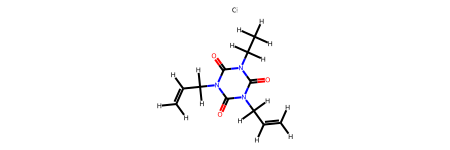

In [18]:
rdkit.Chem.rdmolops.AddHs(a)

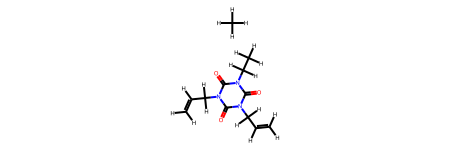

In [19]:
rdkit.Chem.rdmolops.AddHs(b)

In [20]:
gg=['US20070249620A1_p0006_x1375_y2591_c00009.png', 'US20050113580A1_p0038_x1307_y1020_c00053.png', 'US20030130506A1_p0008_x1381_y1349_c00031.png']
imgdir="/home/jovyan/rt-detr/data/real_processed/CLEF_with_charge/images/test"
image_path = f'{imgdir}/{gg[2]}'#


In [21]:
staker_cdf=pd.read_csv(f'staker_with_charge.csv')
staker_cdf_imgs=staker_cdf['img'].to_list()
image_path=staker_cdf_imgs[1]

In [22]:
chemical_elements = [
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne", "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y",
    "Zr", "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn", "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce",
    "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir",
    "Pt", "Au", "Hg", "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th", "Pa", "U", "Np", "Pu", "Am", "Cm",
    "Bk", "Cf", "Es", "Fm", "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds", "Rg", "Cn", "Nh", "Fl", "Mc",
    "Lv", "Ts", "Og"
]

In [23]:
#########################
correcte=[]
uncorrects=[]
debug=False
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/18091.png"
input_s="CC1=CC2C[Ac]=NCCOC=2C=C1"
image_path="/home/jovyan/rt-detr/data/real_processed/staker_with_charge/images/test/49565.png"
input_s="*C1C=C2C([*])=NN=C([U])C2=CN=1"

image_path='/home/jovyan/rt-detr/data/real_processed/USPTO_with_charge/images/test/US07314883-20080101-C00493.png'
input_s='CC1=CC(CO)=CC([N+](=O)[O-])=C1[N+](=O)[O-]'


In [24]:
# Example usage: #change thie image
tensor,w,h = image_to_tensor(image_path)
tensor=tensor.unsqueeze(0)
# print(tensor.size())  # Output tensor shape (C x H x W)

# _model.training=False
_model.eval()#have to uset this
with torch.no_grad():
    # print(_model.training)
    outputs = _model(tensor)
    

ori_size=torch.Tensor([w,h]).long().unsqueeze(0)
result_ = postprocessor(outputs, ori_size)
# result_ = postprocessor(out_, torch.Tensor([w,h]))
score_=result_[0]['scores']
boxe_=result_[0]['boxes']
label_=result_[0]['labels']
selected_indices =score_ > 0.5
output={
    'labels': label_[selected_indices],
    'boxes': boxe_[selected_indices],
    'scores': score_[selected_indices]
}

filtered_output_dict={image_path: output
}


x_center = (output["boxes"][:, 0] + output["boxes"][:, 2]) / 2
y_center = (output["boxes"][:, 1] + output["boxes"][:, 3]) / 2
center_coords = torch.stack((x_center, y_center), dim=1)
output = {'bbox':         output["boxes"].to("cpu").numpy(),
            'bbox_centers': center_coords.to("cpu").numpy(),
            'scores':       output["scores"].to("cpu").numpy(),
            'pred_classes': output["labels"].to("cpu").numpy()}

In [ ]:
#save as onx
import torch.onnx
# 设置为评估模式
_model.eval()
# 定义输出ONNX文件的路径
onnx_model_path = "i2mDETR_model.onnx"
torch.onnx.export(
    model=_model,                     # 要转换的模型
    args=tensor,                 # 模型的输入（示例输入）
    f=onnx_model_path,                # 输出文件的路径
    export_params=True,               # 是否导出训练好的参数
    opset_version=16,                  # 使用更高的 opset 版本dummy_grid
    do_constant_folding=True,         # 是否执行常量折叠优化
    input_names=['input'],            # 输入名称（可选）
    output_names=['output'],          # 输出名称（可选）
    dynamic_axes={
        'input': {0: 'batch_size'},    # 支持动态批量大小
        'output': {0: 'batch_size'}
    }
)

============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================



In [28]:
import onnx
import onnxruntime as ort

In [30]:


# 加载并检查ONNX模型
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX模型检查通过")

# 使用ONNX Runtime进行推理
ort_session = ort.InferenceSession(onnx_model_path)

# 准备输入数据
def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

ort_inputs = {
    ort_session.get_inputs()[0].name: to_numpy(tensor),
    # ort_session.get_inputs()[1].name: to_numpy(dummy_grid)
}
ort_outputs = ort_session.run(None, ort_inputs)

# 获取PyTorch输出
with torch.no_grad():
    torch_output = _model(tensor)

# 打印并比较结果
print("PyTorch输出:", torch_output)
print("ONNX Runtime输出:", ort_outputs[0])

# 计算两者的差异
# difference = np.abs(to_numpy(torch_output) - ort_outputs[0]).max()
# print(f"输出差异最大值: {difference}")


ONNX模型检查通过
PyTorch输出: {'pred_logits': tensor([[[-5.0197, -5.3111, -4.8685,  ..., -4.7331, -5.0557, -7.6984],
         [-5.2138, -5.3650, -5.0374,  ..., -4.9082, -5.0347, -7.7597],
         [-5.0477, -5.6386, -5.4779,  ..., -5.1450, -4.4547, -7.7715],
         ...,
         [-6.0310, -6.5286, -6.0032,  ..., -3.6991, -4.8943, -6.2174],
         [-6.4650, -6.5589, -7.0926,  ..., -5.3570, -7.5832, -7.1826],
         [-6.9540, -6.8163, -6.5456,  ..., -6.5718, -6.5851, -7.5542]]]), 'pred_boxes': tensor([[[0.6279, 0.7861, 0.1100, 0.1731],
         [0.3912, 0.6463, 0.1100, 0.1737],
         [0.6331, 0.3738, 0.1141, 0.1719],
         ...,
         [0.0861, 0.4544, 0.1209, 0.1176],
         [0.2010, 0.5877, 0.0910, 0.0972],
         [0.5608, 0.9512, 0.0740, 0.0755]]])}
ONNX Runtime输出: [[[-5.019729  -5.3111362 -4.8684525 ... -4.733126  -5.0557055 -7.6983805]
  [-5.213763  -5.364949  -5.037431  ... -4.908187  -5.0346828 -7.7596674]
  [-5.047738  -5.6385593 -5.477946  ... -5.1450024 -4.4547076 -7.7

In [31]:
import os
os.getcwd()

'/home/jovyan/rt-detr/rt-detr'

In [24]:
debug=False
if debug:
    import importlib
    importlib.reload(draw_box_utils)
    importlib.reload(src.solver.utils)
    from src.solver.utils import bbox_to_graph_with_charge,mol_from_graph_with_chiral,assemble_atoms_with_charges
    from draw_box_utils import draw_objs,STANDARD_COLORS,draw_text


In [25]:
#visual checking
predict_boxes = output['bbox']
predict_classes = output['pred_classes']
predict_scores = output['scores']

img_ori = Image.open(image_path).convert('RGB')
img_ori_1k = img_ori.resize((1000,1000))
img = Image.open(image_path).convert('RGB')
img = img.resize((1000,1000))

boxed_img = draw_objs(img,
                         predict_boxes*10/3,
                        predict_classes,
                        predict_scores,
                        category_index=idx_to_labels,
                        box_thresh=0.5,
                        line_thickness=3,
                        font='arial.ttf',
                        font_size=10)

In [26]:
charge_list

NameError: name 'charge_list' is not defined

In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

# for i_, atom_s in enumerate(atom_df['atom']):
for i_, row in atoms_df.iterrows():
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        if score_<=0.1:# process cropped_img and try again
            print(s_, "xxx",score_)
            s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')

        index_token[i_]=f'{s_}:{i_}'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)

In [ ]:
from PIL import Image, ImageFilter,ImageEnhance


In [ ]:
pil_l=cropped_img.convert("L")
# binarized_img = pil_l.point(lambda x: 255 if x > 150 else 0, mode="1")
sharpen_kernel = [
    -1, -1, -1,
    -1,  9, -1,
    -1, -1, -1
]
sharpness_factor=2.0
# 应用锐化滤波器
sharpened_img = pil_l.filter(ImageFilter.Kernel((3, 3), sharpen_kernel, scale=1, offset=0))
# 增强锐度
enhancer = ImageEnhance.Sharpness(sharpened_img)
enhanced_img = enhancer.enhance(sharpness_factor)

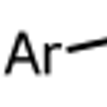

In [ ]:
cropped_img#TODO 对于* 未知box trained 太小

In [ ]:
atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                    bond_labels=bond_labels,  result=[])
smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit
need_cut=[]
ppstr=[]
ppstr_score=[]
crops=[]
index_token=dict()
expan=8#NOTE this control how much the part of bond in crop_Img
mol = rdkit.Chem.RWMol(mol_rebuit)
other2pps=False

print(smiles)
# for i_, atom_s in enumerate(atom_df['atom']):
iiii=0
for i_, row in atoms_df.iterrows():
    iiii+=1
    if "*" in row.atom or "other" in row.atom:
        need_cut.append(i_)
        a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
        box=a * 10/3
        cropped_img = img_ori_1k.crop(box)
        crops.append(cropped_img)
        # Show the cropped image
        # cropped_img.show()
        # cropped_img.save('box_crop01.jpg')
        # Convert PIL Image to a numpy array
        image_np = np.array(cropped_img)
        result = ocr.ocr(image_np, det=False)
        s_, score_ =result[0][0]
        print(s_, score_,"xxxxxxxxxx")
        if score_<=0.1:# process cropped_img and try again
                print(s_, "xxx",score_)
                s_='*'
        if s_=='+' or s_=='-':
            s_="*"
        if len(s_)>1:
            s_=re.sub(r'[^a-zA-Z0-9]', '', s_)#remove special chars
            if re.match(r'^\d+$', s_):print(f'why only numbers ?  {s_}')
        if s_=='L':s_='Li'
        print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
        mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

        ppstr.append(s_)
        ppstr_score.append(score_)
# print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
final_mol = mol.GetMol()
# except Exception as e:
#     print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
#     print(atoms_df)
#     print(image_path,"@@atoms_df for loop")
#     print(e)
#     uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    match = re.match(r'^(\d+)?(.*)', s_)
    if match:
        numeric_part, remaining_part = match.groups()
        if remaining_part in chemical_elements:
            s_=s_
        else:
            s_='*'
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    print(cur_smi,test_smiles)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    new_mol=Chem.MolFromSmiles(new_smi)#if str not belong chemical_elements will failed
    m_noid=remove_atom_number(new_mol)
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    # input_s='[*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO'
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

Cc1cc(CO)cc([N+](=O)[O-])c1[N+](=O)O


In [ ]:
match = re.match(r'^(\d+)?(.*)', "Ar-")
numeric_part, remaining_part = match.groups()

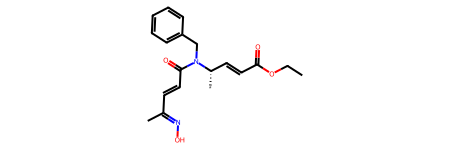

In [ ]:
Chem.MolFromSmiles('[*][C@@H](C=CC(=O)OCC)N(Cc1ccccc1)C(=O)C=CC(C)=NO')

In [ ]:
try:
    atoms_df, bonds_list,charge_list =bbox_to_graph_with_charge(output, idx_to_labels=idx_to_labels,
                                                        bond_labels=bond_labels,  result=[])
    smiles,mol_rebuit=mol_from_graph_with_chiral(atoms_df, bonds_list,charge_list )#NOTE, get SDF from mol_rebuit


    need_cut=[]
    ppstr=[]
    ppstr_score=[]
    crops=[]
    index_token=dict()
    expan=8#NOTE this control how much the part of bond in crop_Img
    mol = rdkit.Chem.RWMol(mol_rebuit)
    other2pps=False

    # for i_, atom_s in enumerate(atom_df['atom']):
    for i_, row in atoms_df.iterrows():
        if "*" in row.atom or "other" in row.atom:
            need_cut.append(i_)
            a=np.array(row.bbox )+np.array([-expan,-expan,expan,expan])#expand crop
            box=a * 10/3
            cropped_img = img_ori_1k.crop(box)
            crops.append(cropped_img)
            image_np = np.array(cropped_img)
            result = ocr.ocr(image_np, det=False)
            s_, score_ =result[0][0]
            print(f'ocr::idx:{i_}',s_, score_ )
            if score_<=0.1:# process cropped_img and try again
                    print(s_, "xxx",score_)
                    s_='*'
            if s_=='+' or s_=='-':
                s_="*"
            if len(s_)>1:
                s_=re.sub(r'[^a-zA-Z0-9\*\-\+]', '', s_)#remove special chars
                if re.match(r'^\d+$', s_):
                    s_=f'{s_}*'#number+ *
                    print(f'why only numbers ?  {s_}')
            if s_=='L':s_='Li'
            match = re.match(r'^(\d+)?(.*)', s_)
            if match:
                numeric_part, remaining_part = match.groups()
                if remaining_part in chemical_elements:
                    s_=s_
                else:
                    if numeric_part:
                        s_=f'{numeric_part}*'
                    else:
                        s_='*'
            index_token[i_]=f'{s_}:{i_}'
            print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
            mol.GetAtomWithIdx(i_).SetProp("atomLabel", f"{s_}")

            ppstr.append(s_)
            ppstr_score.append(score_)
    # print(f"nums: {len(index_token)} '*' need paddleOCR converting",index_token)
    final_mol = mol.GetMol()
except Exception as e:
    print(f"idx:{i_}, atm:{row.atom}-->[{s_}:{i_}] with score:{score_}")
    print(atoms_df)
    print(image_path,"@@atoms_df for loop")
    print(e)
    uncorrects.append(image_path)
    # continue


rdkit_input_s=Chem.MolToSmiles(Chem.MolFromSmiles(input_s),kekuleSmiles=True)
if len(ppstr)==1:
    #just replace * with []
    cur_smi=Chem.MolToSmiles(final_mol,kekuleSmiles=True)#as csv use kekuleSmiles style
    test_smiles=re.sub(r'\*', f'[{s_}]', cur_smi)
    # new_mol=Chem.MolFromSmiles(test_smiles)
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    if rdkit_test_smiles==rdkit_input_s: correcte.append([image_path])

    other2pps=True  
elif len(ppstr)>1:
    index_mol=copy.deepcopy(final_mol)
    show_atom_number(index_mol, 'molAtomMapNumber')
    index_smi=Chem.MolToSmiles(index_mol,kekuleSmiles=True)
    ai_tokens=atomwise_tokenizer(index_smi)
    new_toks=[]
    for k,v in index_token.items():
        for i, atoken in enumerate(ai_tokens):
            if f':{k}' in atoken:
                # index_token[k]
                ai_tokens[i]=re.sub(r'\[.*?\]', f'[{index_token[k]}]', ai_tokens[i])
                print(f':{k},  {atoken} --> [{index_token[k]}] || {ai_tokens[i]}' )
            # new_toks.append(atoken)
    new_smi=''.join(ai_tokens)
    print(f"before replace-->{index_smi}")#TODO NOTE rdkit None* try re way
    print(f"after  replace-->{new_smi}")
    new_mol=Chem.MolFromSmiles(new_smi)
    m_noid=remove_atom_number(new_mol)#TODO this may lead problem
    s_noid=Chem.MolToSmiles(m_noid)
    test_smiles = re.sub(r'\[(\d+)\*', '[*',s_noid)#remove_number_before_star
    test_smiles = remove_SP(test_smiles)
    other2pps=True
    rdkit_test_smiles=Chem.MolToSmiles(Chem.MolFromSmiles(test_smiles),kekuleSmiles=True)
    print(f"final        -->{rdkit_test_smiles}")
    print(f"rdkit_input_s-->{rdkit_test_smiles}")

    if rdkit_test_smiles==rdkit_input_s: correcte.append(image_path)
else:
    uncorrects.append(image_path)
    other2pps=False
# except Exception as e:
#     other2pps=False
#     uncorrects.append(image_path)
#     print(f"not recongnized::{image_path}\n")
#     print(e)

In [ ]:
#TODO get the * with coords, check String OCR, check rebuild process charge and bond missing!!

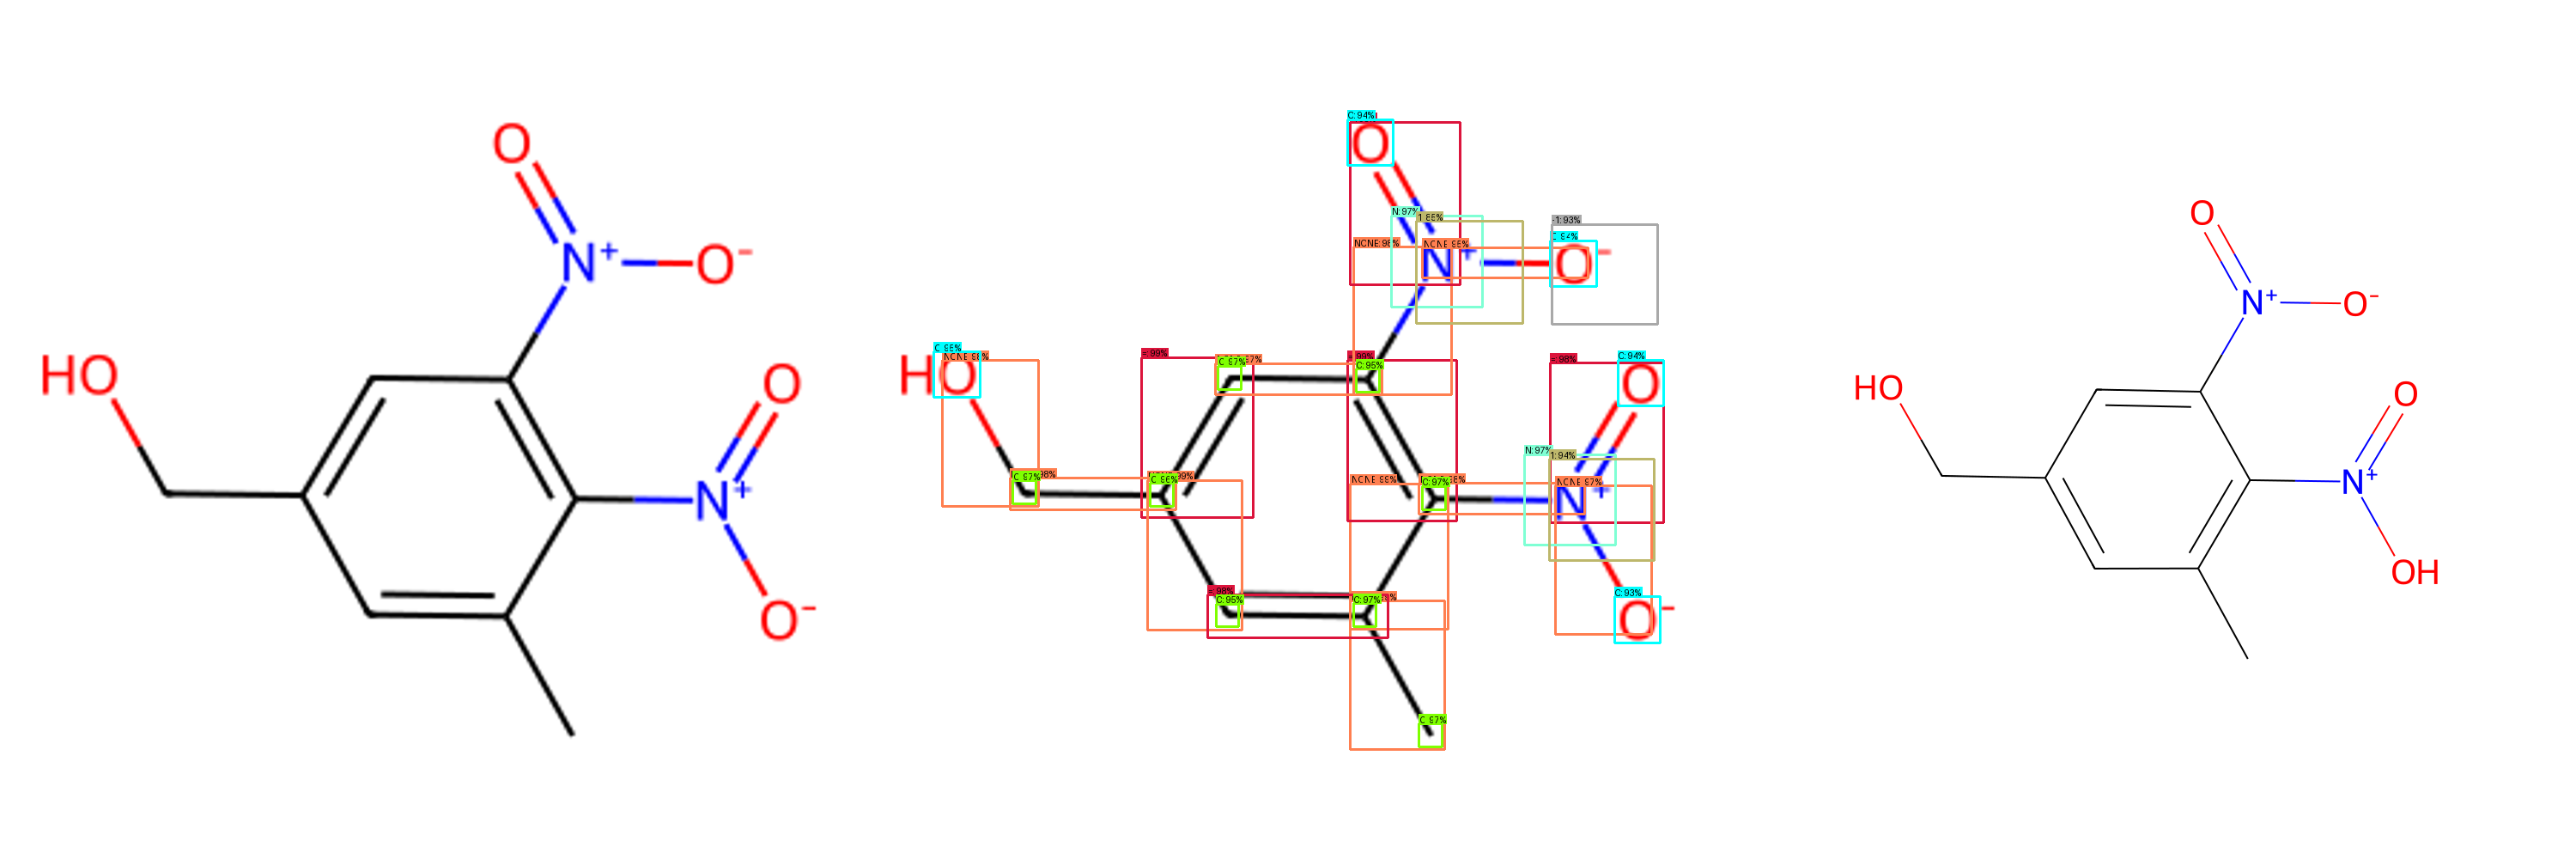

In [ ]:
visual_check=True
# other2pps=True
# TODO #[3H] 2H prpared box for training are too smalled, need adjust
if visual_check:
    img_ori = Image.open(image_path).convert('RGB')
    img_ori_1k = img_ori.resize((1000,1000))
    if other2pps:
        img_rebuit = Draw.MolToImage(final_mol, options=opts,size=(1000, 1000))
    else:
        img_rebuit = Draw.MolToImage(mol_rebuit, options=opts,size=(1000, 1000))
    combined_img = Image.new('RGB', (img_ori_1k.width + boxed_img.width + img_rebuit.width, img_ori_1k.height))
    combined_img.paste(img_ori_1k, (0, 0))
    combined_img.paste(boxed_img, (img_ori_1k.width, 0))
    combined_img.paste(img_rebuit, (img_ori_1k.width + boxed_img.width, 0))
combined_img

In [ ]:
SMI_IDX=Chem.MolToSmiles(final_mol)

NameError: name 'final_mol' is not defined

In [ ]:
from SmilesPE.pretokenizer import atomwise_tokenizer
SMI_IDX=Chem.MolToSmiles(final_mol)
ai_smi=atomwise_tokenizer(SMI_IDX)

In [ ]:
print(ai_smi)

['[NH:1]', '(', '[OH:2]', ')', '[C:17]', '(', '=', '[O:4]', ')', '[CH:7]', '1', '[N:3]', '(', '[S@SP2:12]', '(', '[c:6]', '2', '[cH:11]', '[cH:9]', '[c:15]', '(', '[O:14]', '[*:19]', ')', '[cH:5]', '[cH:23]', '2', ')', '(', '=', '[O:8]', ')', '=', '[O:16]', ')', '[CH2:10]', '[*:18]', '[*:20]', '[C:13]', '1', '(', '[*:21]', ')', '[*:22]']


In [ ]:
Chem.MolToSmiles(mol, canonical=False, doRandom=False, isomericSmiles=True, 
            kekuleSmiles=True)



'CCCC'

In [ ]:
Chem.MolToSmiles(mol)

'[*:1][CH2:2][CH2:3][CH3:4]'

In [ ]:
#TODO rotable boxing  and aromatic bonding rings??

In [ ]:
['US20070249620A1_p0006_x1375_y2591_c00009.png', 'US20050182067A1_p0032_x1638_y1021_c00113.png', 'US20050113580A1_p0038_x1307_y1020_c00053.png', 'US20030130506A1_p0008_x1381_y1349_c00031.png', 'US20050054819A1_p0033_x1376_y0730_c00118.png', 'US20060281700A1_p0083_x0404_y0649_c00163.png', 'US20050182067A1_p0036_x1607_y2740_c00137.png', 'US20070270434A1_p0018_x1376_y0766_c00041.png']

['US20070249620A1_p0006_x1375_y2591_c00009.png',
 'US20050182067A1_p0032_x1638_y1021_c00113.png',
 'US20050113580A1_p0038_x1307_y1020_c00053.png',
 'US20030130506A1_p0008_x1381_y1349_c00031.png',
 'US20050054819A1_p0033_x1376_y0730_c00118.png',
 'US20060281700A1_p0083_x0404_y0649_c00163.png',
 'US20050182067A1_p0036_x1607_y2740_c00137.png',
 'US20070270434A1_p0018_x1376_y0766_c00041.png']

In [ ]:
# original_smiles::: CC1=C[U]=C(N2CCN(C)CC2)C=C1
# test_smiles::: Cc1c*c(N2CCN(C)CC2)cc1
# file_name:: US20070249620A1_p0006_x1375_y2591_c00009.png
# original_smiles::: COC1=C([N+](=O)[O-])C(N)=CC=C1
# test_smiles::: COc1cccc(N)c1NO.O
# file_name:: US20050182067A1_p0032_x1638_y1021_c00113.png
# original_smiles::: COC(=O)CC1=CC=CC(OCCCN(CC2=CC=CC(C(F)(F)F)=C2Cl)C[C@H](OC(=O)C2=CC=CC=C2)C2=CC=CC=C2)=C1
# test_smiles::: C.COC(=O)Cc1cccc(OCCCN(Cc2cccc(C(F)(F)F)c2Cl)C[C@@H]2OC(=O)c3cc2cccc(C)ccc3)c1
# file_name:: US20050113580A1_p0038_x1307_y1020_c00053.png
# original_smiles::: [*]C1([*])*[W]CN(S(=O)(=O)C2=CC=C(O[Ar])C=C2)C1C(=O)NO
# test_smiles::: *Oc1ccc([S](=O)(=O)N2C**C(*)(*)C2C(=O)NO)cc1
# file_name:: US20030130506A1_p0008_x1381_y1349_c00031.png
# original_smiles::: [C-]#[N+]CC1=CN=CC=C1
# test_smiles::: C.NCc1cccnc1
# file_name:: US20050054819A1_p0033_x1376_y0730_c00118.png
# original_smiles::: O=[N+]([O-])C1=CN=C(OC2CCC2)C=C1
# test_smiles::: O.ONc1ccc(OC2CCC2)nc1
# file_name:: US20060281700A1_p0083_x0404_y0649_c00163.png
# original_smiles::: O=C1COC2=CC=CC([N+](=O)[O-])=C2N1
# test_smiles::: O.O=Nc1cccc2c1NC(=O)CO2
# file_name:: US20050182067A1_p0036_x1607_y2740_c00137.png
# original_smiles::: [C-]#[N+]CC1=CC=C(OC(F)(F)F)C=C1
# test_smiles::: C#N.Cc1ccc(OC(F)(F)F)cc1
# file_name:: US20070270434A1_p0018_x1376_y0766_c00041.png
#

#TODO check the above wrongs and try fix

In [ ]:
res_smiles=[]
for i,(key,value) in enumerate(filtered_output_dict.items()):
    result = []
    res_smiles.append(output_to_smiles(value,idx_to_labels,bond_labels,result)) 

In [ ]:
#prediction postprocesss 
logits, boxes = outputs['pred_logits'], outputs['pred_boxes']
scores =  torch.nn.functional.sigmoid(logits)
bbox_pred = torchvision.ops.box_convert(boxes, in_fmt='cxcywh', out_fmt='xyxy')
labels_scores = torch.nn.functional.softmax(logits,dim=-1)
labels_pred = torch.argmax(labels_scores,dim=-1)

In [ ]:
ori_size=torch.Tensor([w,h]).long().unsqueeze(0)